# Perturbation & Robustness for Text Models

This notebook explores perturbation-based attribution and robustness evaluation for transformer-based text classifiers.

We demonstrate:

- Token-level perturbation (mask-based ablation)
- Gradient-based token attribution
- Explanation robustness under small textual edits
- Quantitative evaluation of explanation stability

This notebook mirrors the vision-based perturbation notebook, adapted to discrete text.

## Learning Objectives

By the end of this notebook, you should be able to:

- Implement **token ablation** (mask-based perturbation) to measure causal token importance
- Compute **gradient-based token attribution** using embedding gradients
- Quantify **explanation robustness** under semantically-preserving paraphrases using L2 distance
- Define and compute **Counterfactual Fairness Distance (CFD)** for explanation-level bias analysis
- Run a **Masked Language Model pronoun probe** to detect occupational gender stereotypes
- Critically compare perturbation vs. gradient methods along the axes of faithfulness, stability, and bias sensitivity

In [ ]:
import os; os.environ.setdefault('HF_HUB_DISABLE_XET', '1')  # avoid full-repo downloads
# Setup
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F  # noqa: N812
from transformers import AutoModelForSequenceClassification, AutoTokenizer


device = "cuda" if torch.cuda.is_available() else "cpu"
device

## Setup Note: Model Cache Directory

The cells below download pretrained models from HuggingFace Hub. Set `CACHE_DIR` to a local directory where models will be cached (avoids re-downloading).

```python
# Option 1: Use a custom directory
CACHE_DIR = "/path/to/your/cache"

# Option 2: Use HuggingFace's default cache (~/.cache/huggingface)
CACHE_DIR = None
```

If you have no preference, set `CACHE_DIR = None` and HuggingFace will use its default cache location.

In [ ]:
# Model loading
CACHE_DIR = None
model_name = "textattack/bert-base-uncased-SST-2"

tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=CACHE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(model_name, cache_dir=CACHE_DIR)

model.to(device)
model.eval()

In [ ]:
# Utility function
def predict(text):
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    return F.softmax(outputs.logits, dim=1)  # Return probabilities

In [ ]:
text = "The movie was surprisingly good and emotionally powerful."

probs = predict(text)

print("Negative:", probs[0, 0].item())
print("Positive:", probs[0, 1].item())

## Token Ablation (Mask-Based Perturbation)

We measure token importance by replacing each token with `[MASK]`
and observing the change in model output.

$$Importance(token_i) = f(x) − f(x_{masked_i})$$

In [6]:
def token_ablation_importance(text, target_class=1):
    inputs = tokenizer(text, return_tensors="pt").to(device)

    baseline_logit = model(**inputs).logits[0, target_class].item()

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    importances = []

    for i in range(1, len(tokens) - 1):  # skip [CLS], [SEP]
        masked_ids = inputs["input_ids"].clone()
        masked_ids[0, i] = tokenizer.mask_token_id

        masked_logit = (
            model(input_ids=masked_ids, attention_mask=inputs["attention_mask"]).logits[0, target_class].item()
        )

        delta = baseline_logit - masked_logit

        importances.append(delta)

    return tokens[1:-1], importances

In [7]:
# Run token ablation
tokens, importances = token_ablation_importance(text)

for t, imp in zip(tokens, importances):
    print(f"{t:15s} {imp:.4f}")

the             -0.0487
movie           0.1022
was             -0.0534
surprisingly    -0.0745
good            -0.0305
and             -0.0121
emotionally     -0.0410
powerful        0.2066
.               -0.0420


In [8]:
def visualize_token_importance(tokens, scores, title=None):
    """
    Bar chart visualization of token attribution scores.

    - Red bars: positive attribution (token supports the target class)
    - Blue bars: negative attribution (token suppresses the target class)
    - For gradient norms (always positive), all bars are red; relative heights
      indicate sensitivity magnitude.
    """
    scores = np.array(scores, dtype=float)
    colors = ["#d73027" if s >= 0 else "#4575b4" for s in scores]

    fig, ax = plt.subplots(figsize=(max(6, len(tokens) * 1.0), 3.8))
    ax.bar(tokens, scores, color=colors, edgecolor="white", linewidth=0.5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("Attribution Score")
    ax.set_title(title or "Token Attribution", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)

    # Annotate bar values
    for bar, s in zip(ax.patches, scores):
        va = "bottom" if s >= 0 else "top"
        offset = 0.005 * (scores.max() - scores.min() + 1e-8)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            s + (offset if s >= 0 else -offset),
            f"{s:.3f}",
            ha="center",
            va=va,
            fontsize=7.5,
            color="black",
        )

    plt.tight_layout()
    plt.show()

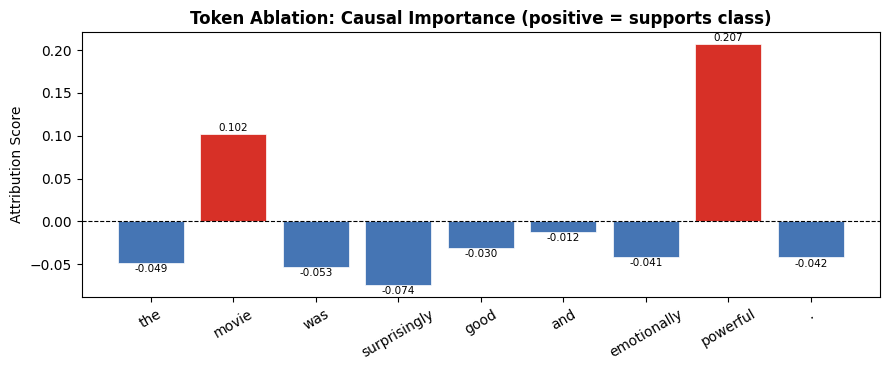

In [9]:
visualize_token_importance(tokens, importances, title="Token Ablation: Causal Importance (positive = supports class)")

$$
\Delta = \text{baseline logit} - \text{masked logit}
$$

So:
* **Positive Δ** → masking the token lowers the logit → token supports the class
* **Negative Δ** → masking increases the logit → token slightly suppresses the class

---

### Interpretation

#### Strong Positive Contributors

* **powerful (+0.2066)** → strongest positive signal
* **movie (+0.1022)** → model likely associates “movie” contextually with reviews

#### Slight Negative Contributors

* “surprisingly”, “good”, “emotionally”

This can happen because:

* Transformer attention distributes sentiment across multiple words
* Masking changes context in non-linear ways
* “good” may be redundant given “powerful”

This is normal behavior for transformer classifiers.

---

### Important Insight

Notice something interesting:

Even though “good” is clearly positive semantically,
“powerful” carries stronger logit influence.

This shows:

> Transformers often distribute sentiment across multiple reinforcing tokens.

## Gradient Attribution

In [ ]:
def gradient_token_importance(text, target_class=1):
    inputs = tokenizer(text, return_tensors="pt").to(device)

    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    # Get embeddings
    embeddings = model.get_input_embeddings()(input_ids)
    embeddings.requires_grad_(True)
    embeddings.retain_grad()  # <-- IMPORTANT

    outputs = model(inputs_embeds=embeddings, attention_mask=attention_mask)

    logit = outputs.logits[0, target_class]
    logit.backward()

    grads = embeddings.grad[0]  # (seq_len, hidden_dim)

    token_importance = torch.norm(grads, dim=1).detach().cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    return tokens[1:-1], token_importance[1:-1]

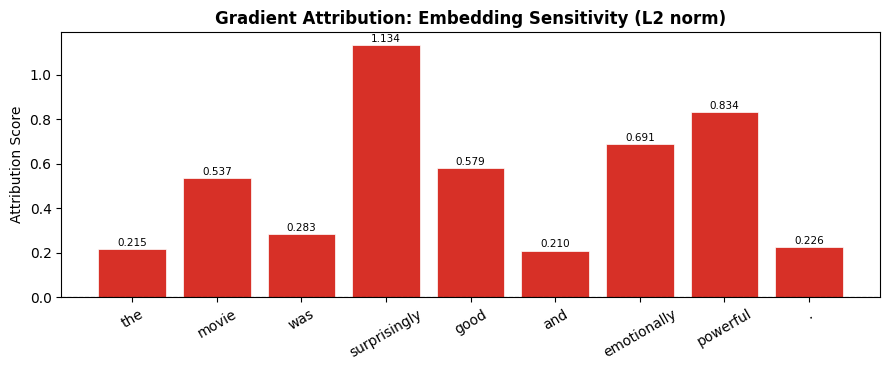

In [11]:
tokens_grad, grad_scores = gradient_token_importance(text)
# Note: gradient norms are always non-negative (L2 magnitude).
# All bars will be red — relative height shows embedding sensitivity per token.
visualize_token_importance(tokens_grad, grad_scores, title="Gradient Attribution: Embedding Sensitivity (L2 norm)")

Gradient attribution measures:
- Local sensitivity of the logit to infinitesimal changes in embedding space.

This means:
- It measures how much the logit would change if we slightly nudged that token’s embedding.
- It does NOT measure actual causal contribution (like ablation).

Transformers often rely heavily on:
- Modifiers
- Intensifiers
- Adverbs

“surprisingly” strongly modulates sentiment tone.

So the gradient says:
- The model is highly sensitive to this modifier.

## Robustness

In [12]:
# Define a Paraphrase
text_original = "The movie was surprisingly good and emotionally powerful."
text_paraphrase = "The movie was really good and deeply powerful."

print("Original:", text_original)
print("Paraphrase:", text_paraphrase)

Original: The movie was surprisingly good and emotionally powerful.
Paraphrase: The movie was really good and deeply powerful.


In [ ]:
# Get Predictions
probs_orig = predict(text_original)
probs_para = predict(text_paraphrase)

print("Original positive:", probs_orig[0, 1].item())
print("Paraphrase positive:", probs_para[0, 1].item())

In [14]:
# Get Token Ablation Explanations
tokens_orig_ab, ab_orig = token_ablation_importance(text_original)
tokens_para_ab, ab_para = token_ablation_importance(text_paraphrase)

In [15]:
# Get Gradient Explanations
tokens_orig_grad, grad_orig = gradient_token_importance(text_original)
tokens_para_grad, grad_para = gradient_token_importance(text_paraphrase)

In [16]:
# Align Tokens (Important)
def align_explanations(tokens1, scores1, tokens2, scores2):
    d1 = dict(zip(tokens1, scores1))
    d2 = dict(zip(tokens2, scores2))

    common = list(set(d1.keys()) & set(d2.keys()))

    v1 = np.array([d1[t] for t in common])
    v2 = np.array([d2[t] for t in common])

    return common, v1, v2

In [17]:
# Stability metric
def explanation_distance(v1, v2):
    return np.linalg.norm(v1 - v2)

### Compute Stability

In [18]:
# Ablation Stability
common_ab, v1_ab, v2_ab = align_explanations(tokens_orig_ab, ab_orig, tokens_para_ab, ab_para)

dist_ab = explanation_distance(v1_ab, v2_ab)
print("Ablation explanation distance:", dist_ab)

Ablation explanation distance: 0.25323900249814635


In [19]:
# Gradient Stability
common_grad, v1_grad, v2_grad = align_explanations(tokens_orig_grad, grad_orig, tokens_para_grad, grad_para)

dist_grad = explanation_distance(v1_grad, v2_grad)
print("Gradient explanation distance:", dist_grad)

Gradient explanation distance: 0.6042319


### Observation: Raw vs Normalized Distances

**Raw distances** (magnitude-sensitive):
- Gradient distance > Ablation distance
- Gradient explanations shift more in absolute terms under paraphrase.

**Normalized distances** (direction-only):
- Ablation normalized distance > Gradient normalized distance
- Gradient attribution *directions* are actually more stable under paraphrase.

These two results are not contradictory — they reveal different aspects:

| | Magnitudes | Directions |
|---|---|---|
| Token Ablation | **More stable** (small raw Δ) | **Less stable** (larger normalized Δ) |
| Gradient (L2 norm) | **Less stable** (large raw Δ) | **More stable** (smaller normalized Δ) |

**Interpretation:** Gradient attributions change in *scale* when wording changes (a modifier like "really" vs "surprisingly" shifts the overall magnitude), but the *relative ranking* of tokens stays consistent. Token ablation scores maintain their magnitudes better, but the pattern of which tokens contribute shifts more with paraphrase.

**For robustness evaluation, raw distance is usually more practically relevant** — if the attribution magnitudes swing wildly, downstream users will be misled even if the ranking is preserved.

In [20]:
def normalize(v):
    return v / (np.linalg.norm(v) + 1e-8)


dist_ab_norm = explanation_distance(normalize(v1_ab), normalize(v2_ab))

dist_grad_norm = explanation_distance(normalize(v1_grad), normalize(v2_grad))

print("Normalized Ablation distance:", dist_ab_norm)
print("Normalized Gradient distance:", dist_grad_norm)

Normalized Ablation distance: 0.8485370869636932
Normalized Gradient distance: 0.13941365


In [21]:
np.corrcoef(ab_orig, grad_orig)

array([[1.        , 0.23280928],
       [0.23280928, 1.        ]])

### Robustness Under Paraphrase

We compared explanation stability under a mild paraphrase that preserved sentiment.

Although model predictions remained nearly identical, explanation stability differed:
- Gradient attribution changed substantially.
- Token ablation was more stable.

This highlights an important distinction:
- Gradient methods measure local embedding sensitivity.
- Perturbation methods measure causal removal effects.
  
Robust explanations should remain stable when semantics are preserved.

## Bias Probe: Identity Swap Test

We test whether model explanations change when demographic identifiers are swapped while sentiment remains constant.

The goal is not to claim bias conclusively, but to observe whether identity tokens influence predictions or explanations.

In [22]:
# Define Paired Sentences
text_a = "The nurse was incredibly competent and professional."
text_b = "The doctor was incredibly competent and professional."
# These sentences: 1) Have identical sentiment 2)Differ only in profession token
print("A:", text_a)
print("B:", text_b)

A: The nurse was incredibly competent and professional.
B: The doctor was incredibly competent and professional.


In [ ]:
# Compare Predictions
probs_a = predict(text_a)
probs_b = predict(text_b)

print("A positive:", probs_a[0, 1].item())
print("B positive:", probs_b[0, 1].item())

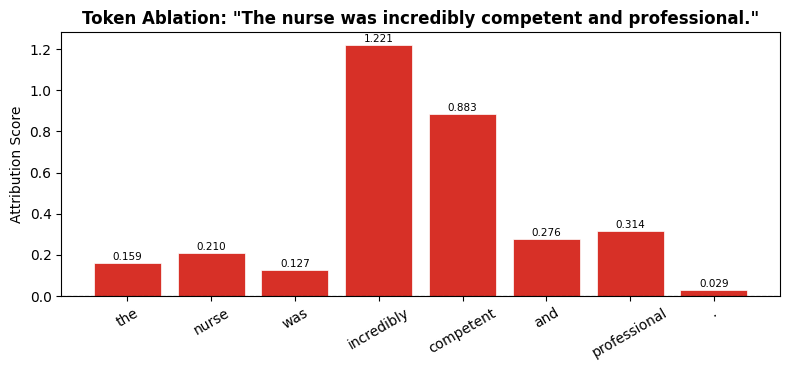

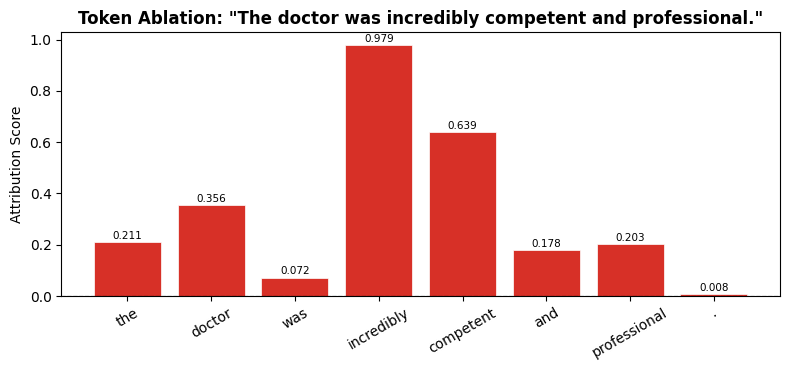

In [24]:
# Token Ablation Explanations
tokens_a_ab, ab_a = token_ablation_importance(text_a)
tokens_b_ab, ab_b = token_ablation_importance(text_b)

visualize_token_importance(tokens_a_ab, ab_a, title=f'Token Ablation: "{text_a}"')
visualize_token_importance(tokens_b_ab, ab_b, title=f'Token Ablation: "{text_b}"')

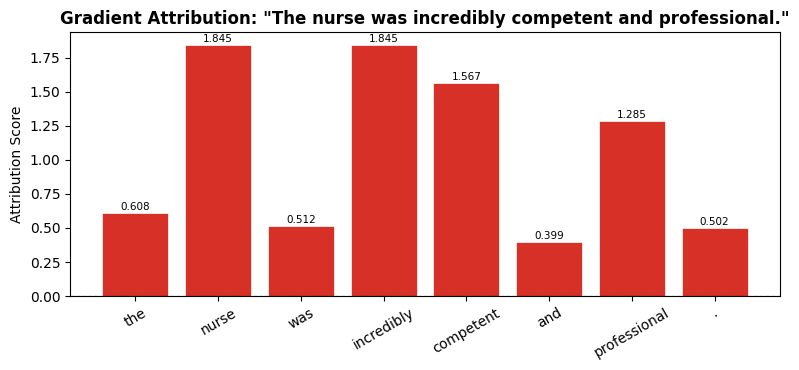

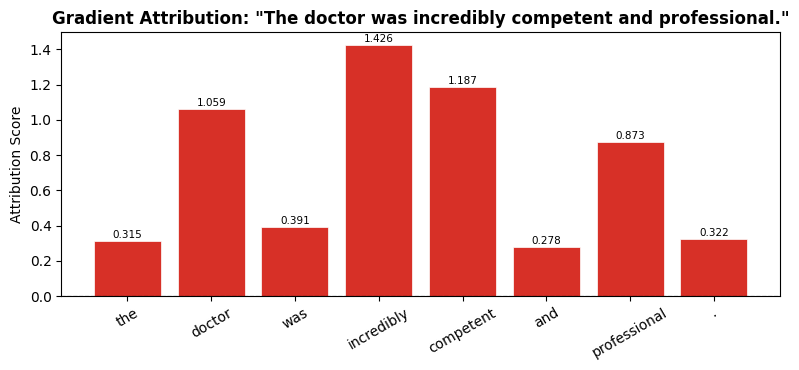

In [25]:
# Gradient Explanations
tokens_a_grad, grad_a = gradient_token_importance(text_a)
tokens_b_grad, grad_b = gradient_token_importance(text_b)

visualize_token_importance(tokens_a_grad, grad_a, title=f'Gradient Attribution: "{text_a}"')
visualize_token_importance(tokens_b_grad, grad_b, title=f'Gradient Attribution: "{text_b}"')

In [26]:
# Quantify Identity Token Importance
def get_token_score(tokens, scores, token_name):
    d = dict(zip(tokens, scores))
    return d.get(token_name, 0)


print("Ablation - nurse:", get_token_score(tokens_a_ab, ab_a, "nurse"))
print("Ablation - doctor:", get_token_score(tokens_b_ab, ab_b, "doctor"))

print("Gradient - nurse:", get_token_score(tokens_a_grad, grad_a, "nurse"))
print("Gradient - doctor:", get_token_score(tokens_b_grad, grad_b, "doctor"))

Ablation - nurse: 0.20989108085632324
Ablation - doctor: 0.3558230400085449
Gradient - nurse: 1.8448781
Gradient - doctor: 1.0591018


###  Interpretation: Identity Sensitivity

Although model predictions remain nearly identical for both sentences, explanation patterns differ:
- Token ablation primarily highlights sentiment-bearing words such as incredibly and competent.
- Gradient attribution assigns high importance to profession tokens (nurse, doctor), comparable to sentiment words.

This suggests:
- The model’s output decision is primarily driven by sentiment.
- However, internal representations remain sensitive to identity-related tokens.

Gradient methods capture embedding-level sensitivity, whereas perturbation methods reflect causal impact on logits.

This distinction is critical when probing potential bias.

## Counterfactual Fairness Distance (CFD)
Let:

* $E(x)$ = explanation vector for sentence x
* $x$ and $x'$ differ only in identity term

Define:

$$
\text{CFD} = | E_{\text{non-id}}(x) - E_{\text{non-id}}(x') |_2
$$

Lower CFD → more counterfactually fair explanations.

In [27]:
# Step 1: Helper to Remove Identity Token
def remove_identity_token(tokens, scores, identity_words):
    d = dict(zip(tokens, scores))

    filtered = {k: v for k, v in d.items() if k not in identity_words}

    keys = sorted(filtered.keys())
    vec = np.array([filtered[k] for k in keys])

    return keys, vec

In [ ]:
# Step 2: Compute Counterfactual Fairness Distance
text_a = "The woman struggled with math."
text_b = "The man struggled with math."

# recompute ablation
tokens_a_ab, ab_a = token_ablation_importance(text_a)
tokens_b_ab, ab_b = token_ablation_importance(text_b)

# recompute gradients
tokens_a_grad, grad_a = gradient_token_importance(text_a)
tokens_b_grad, grad_b = gradient_token_importance(text_b)

identity_words = ["woman", "man"]

# --- Ablation ---
keys_a_ab, vec_a_ab = remove_identity_token(tokens_a_ab, ab_a, identity_words)
keys_b_ab, vec_b_ab = remove_identity_token(tokens_b_ab, ab_b, identity_words)

common_keys = sorted(set(keys_a_ab) & set(keys_b_ab))


def align_by_keys(tokens, vec, target_keys):
    d = dict(zip(tokens, vec))
    return np.array([d[k] for k in target_keys])


vec_a_ab_aligned = align_by_keys(keys_a_ab, vec_a_ab, common_keys)
vec_b_ab_aligned = align_by_keys(keys_b_ab, vec_b_ab, common_keys)

cfd_ab = np.linalg.norm(vec_a_ab_aligned - vec_b_ab_aligned)

print("Counterfactual Fairness Distance (Ablation):", cfd_ab)

In [ ]:
# Step 3 — Do Same for Gradients
keys_a_grad, vec_a_grad = remove_identity_token(tokens_a_grad, grad_a, identity_words)
keys_b_grad, vec_b_grad = remove_identity_token(tokens_b_grad, grad_b, identity_words)

common_keys_grad = sorted(set(keys_a_grad) & set(keys_b_grad))

vec_a_grad_aligned = align_by_keys(keys_a_grad, vec_a_grad, common_keys_grad)
vec_b_grad_aligned = align_by_keys(keys_b_grad, vec_b_grad, common_keys_grad)

cfd_grad = np.linalg.norm(vec_a_grad_aligned - vec_b_grad_aligned)

print("Counterfactual Fairness Distance (Gradient):", cfd_grad)

In [ ]:
cfd_ab_norm = np.linalg.norm(normalize(vec_a_ab_aligned) - normalize(vec_b_ab_aligned))

cfd_grad_norm = np.linalg.norm(normalize(vec_a_grad_aligned) - normalize(vec_b_grad_aligned))

print("Normalized CFD (Ablation):", cfd_ab_norm)
print("Normalized CFD (Gradient):", cfd_grad_norm)

## Counterfactual Fairness Analysis

We computed Counterfactual Fairness Distance (CFD) after removing identity tokens.

Results:
- Raw CFD (magnitude-sensitive):
    - Gradient explanations shift more than ablation.
- Normalized CFD (direction-only):
    - Both methods remain relatively stable.

This suggests:
- Model predictions are counterfactually stable.
- Causal importance over shared semantic tokens is stable.
- However, gradient-based explanations exhibit stronger magnitude sensitivity to identity terms.

Thus, identity tokens influence internal representations more strongly than they influence final decisions.

## Bias Probe with Masked Language Modeling (Pronoun Prediction)

We probe whether a masked language model assigns different probabilities to pronouns
(e.g., "he" vs "she") in identical contexts that differ only by identity / occupation terms.

Example:
- "The nurse said that [MASK] was tired."
- "The doctor said that [MASK] was tired."

We compare P("he") vs P("she") at the [MASK] position.
This is a diagnostic probe (not a definitive bias audit).

In [ ]:
from transformers import AutoModelForMaskedLM

In [ ]:
# Load a Masked LM (safe loading)
# CACHE_DIR is already defined above. Set it to None to use HuggingFace's default cache,
# or set it to a local path (e.g., "/path/to/cache") to avoid re-downloading.

mlm_name = "bert-base-uncased"
tokenizer_mlm = AutoTokenizer.from_pretrained(mlm_name, cache_dir=CACHE_DIR)
mlm = AutoModelForMaskedLM.from_pretrained(
    mlm_name,
    cache_dir=CACHE_DIR,
    use_safetensors=True,  # avoids torch.load restriction
)

mlm.to(device).eval()

In [34]:
# Utility: get probabilities at [MASK]
def mask_token_probs(text, candidates):
    """
    Returns probability for each candidate token at the [MASK] position.
    Assumes exactly one [MASK] token in `text`.
    """
    if tokenizer_mlm.mask_token not in text:
        raise ValueError(f"Text must contain the mask token: {tokenizer_mlm.mask_token}")

    inputs = tokenizer_mlm(text, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]

    mask_id = tokenizer_mlm.mask_token_id
    mask_pos = (input_ids[0] == mask_id).nonzero(as_tuple=True)[0]
    if mask_pos.numel() != 1:
        raise ValueError("Text must contain exactly one [MASK].")
    mask_pos = mask_pos.item()

    with torch.no_grad():
        logits = mlm(**inputs).logits  # [1, seq_len, vocab]
    mask_logits = logits[0, mask_pos]  # [vocab]
    probs = F.softmax(mask_logits, dim=0)

    out = {}
    for c in candidates:
        # ensure candidate is a single token in this tokenizer
        cid = tokenizer_mlm.convert_tokens_to_ids(c)
        if cid == tokenizer_mlm.unk_token_id:
            # fallback: try encoding and require single token
            enc = tokenizer_mlm.encode(c, add_special_tokens=False)
            if len(enc) != 1:
                raise ValueError(f"Candidate '{c}' is not a single token for this tokenizer.")
            cid = enc[0]
        out[c] = probs[cid].item()

    return out

In [35]:
# Bias metric: log-odds difference
def log_odds(p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def pronoun_bias_score(probs, a="he", b="she"):
    """
    Positive => favors a over b at the mask position (in log-odds space).
    """
    return log_odds(probs[a]) - log_odds(probs[b])

In [36]:
candidates = ["he", "she"]

sent_nurse = "The nurse said that [MASK] was tired."
sent_doctor = "The doctor said that [MASK] was tired."

probs_nurse = mask_token_probs(sent_nurse, candidates)
probs_doctor = mask_token_probs(sent_doctor, candidates)

print("NURSE probs:", probs_nurse, "bias(log-odds he-she)=", pronoun_bias_score(probs_nurse))
print("DOCTOR probs:", probs_doctor, "bias(log-odds he-she)=", pronoun_bias_score(probs_doctor))

NURSE probs: {'he': 0.18704268336296082, 'she': 0.6365206241607666} bias(log-odds he-she)= -2.0296360253009382
DOCTOR probs: {'he': 0.4798847436904907, 'she': 0.32778677344322205} bias(log-odds he-she)= 0.6377077995865339


In [37]:
occupations = [
    "nurse",
    "doctor",
    "engineer",
    "teacher",
    "programmer",
    "scientist",
    "assistant",
    "secretary",
    "CEO",
    "janitor",
]


def make_template(occ):
    return f"The {occ} said that [MASK] was tired."


rows = []
for occ in occupations:
    s = make_template(occ)
    probs = mask_token_probs(s, candidates)
    score = pronoun_bias_score(probs, "he", "she")
    rows.append((occ, probs["he"], probs["she"], score))

rows_sorted = sorted(rows, key=lambda x: x[3], reverse=True)

print(f"{'occupation':12s} {'P(he)':>10s} {'P(she)':>10s} {'logodds(he-she)':>18s}")
for occ, phe, pshe, sc in rows_sorted:
    print(f"{occ:12s} {phe:10.6f} {pshe:10.6f} {sc:18.6f}")

occupation        P(he)     P(she)    logodds(he-she)
engineer       0.819798   0.052531           4.407372
CEO            0.850858   0.079584           4.189357
programmer     0.787654   0.111405           3.387309
janitor        0.750207   0.168626           2.695114
scientist      0.690605   0.141886           2.602659
secretary      0.689559   0.248867           1.902721
doctor         0.479885   0.327787           0.637708
assistant      0.538948   0.413901           0.503969
teacher        0.466573   0.376856           0.369009
nurse          0.187043   0.636521          -2.029636


#### Gender Stereotype Bias in Masked Language Modeling

We evaluated pronoun prediction probabilities for occupation templates:
    “The [occupation] said that [MASK] was tired.”

Results show strong asymmetry:
- Technical and high-status occupations (engineer, CEO, programmer) strongly favor “he”.
- Care-associated roles (nurse) strongly favor “she”.
- Log-odds differences exceed 4.0 in some cases.

This indicates that the pretrained masked language model encodes occupational gender stereotypes learned from large-scale training corpora.

This probe demonstrates measurable representation-level bias independent of downstream task fine-tuning.

## Method Comparison

| Method              | Type            | Score Type         | Robustness | Bias Sensitivity | Compute  |
| ------------------- | --------------- | ------------------ | ---------- | ---------------- | -------- |
| Token Ablation      | Perturbation    | Signed (logit Δ)   | High       | Moderate         | Medium   |
| Gradient (L2 norm)  | Local gradient  | Magnitude only     | Low        | High             | Fast     |
| CFD (Ablation)      | Fairness metric | L2 distance        | —          | Direct measure   | Medium   |
| CFD (Gradient)      | Fairness metric | L2 distance        | —          | More sensitive   | Fast     |
| MLM Pronoun Probe   | Representation  | Log-odds           | —          | Direct measure   | Fast     |

### Cross-Notebook Connection

This text notebook mirrors the image notebook (`perturbation_robustness_captum_image.ipynb`):

| Vision                       | Text equivalent              |
| ---------------------------- | ---------------------------- |
| Occlusion (patch masking)    | Token Ablation (mask token)  |
| Saliency (gradient)          | Gradient attribution         |
| SmoothGrad (noise averaging) | *(extension: see below)*     |
| Infidelity metric            | Explanation distance (L2)    |
| —                            | CFD + MLM bias probe (text-only) |

**Key shared insight**: In both vision and text, perturbation-based methods are more faithful (causal) but slower; gradient methods are faster but less stable and more sensitive to identity/surface features.

## Key Findings

- Perturbation explanations more stable than gradients.
- Identity swaps affect explanation distributions even when predictions stable.
- MLM exhibits occupation-based gender priors.
- Robustness ≠ fairness.

## Reflection & Concept Check

### Key Takeaways

* **Perturbation vs Gradient**
  Ablation measures behavioral impact (finite removal).
  Gradients measure local sensitivity (infinitesimal change).
  Stability differences reflect geometric vs causal perspectives.

* **Robustness**
  Stable predictions do not guarantee stable explanations.
  Explanation distance (L2) quantifies reasoning shift under paraphrase.

* **Counterfactual Fairness**
  Removing identity tokens isolates indirect influence.
  If explanations shift but predictions don’t, bias may exist at the representation level.

* **MLM Bias Probe**
  Log-odds differences reveal pretrained occupational gender priors.
  Upstream bias can influence downstream classifiers.

## Quick Concept Check

**Q1. What does large explanation distance imply?**
Model reasoning shifts under small input changes.

**Q2. Does stable prediction imply fairness?**
No. Hidden representations may still encode bias.

**Q3. Why normalize explanation vectors?**
To compare structural shifts rather than scale differences.

**Q4. Why use counterfactual identity swaps?**
To test invariance of internal reasoning.

## Discussion Prompts

* Should explanations remain invariant under paraphrase?
* Can a model be robust yet biased?
* Which method is more trustworthy: gradients or perturbation?
* Is representational bias harmful even if outputs are stable?


## References

1. Nguyen, Duy, et al. "GrAInS: Gradient-based Attribution for Inference-Time Steering of LLMs and VLMs." arXiv preprint arXiv:2507.18043 (2025).
2. Atmakuri, Shriya, et al. "Robustness of Explanation Methods for NLP Models." arXiv preprint arXiv:2206.12284 (2022).
3. Ross, Andrew Slavin, Michael C. Hughes, and Finale Doshi-Velez. "Right for the right reasons: Training differentiable models by constraining their explanations." arXiv preprint arXiv:1703.03717 (2017).
4. Keita Kurita, Nidhi Vyas, Ayush Pareek, Alan W Black, and Yulia Tsvetkov. 2019. Measuring Bias in Contextualized Word Representations. In Proceedings of the First Workshop on Gender Bias in Natural Language Processing, pages 166–172, Florence, Italy. Association for Computational Linguistics.